# Parcel Invoice Analysis — Normalized Shipment Cost Model

**Context:** A shoe company ships 4 lb parcels domestically across India via carriers like Delhivery, DTDC, Blue Dart, Ekart, and others. The invoice data contains multiple charge lines per shipment. The goal is to build a normalized cost per shipment so that carriers can be compared fairly.

**AI Tool Usage:** Gemini was used to help classify the 196 distinct charge type labels in this dataset into categories (base, surcharge, penalty, exclude). This is a judgment-heavy step where understanding of Indian domestic carrier billing conventions matters — I used Gemini to draft an initial mapping and then reviewed each category manually. All code, analysis decisions, and written observations are my own.


## 1. Setup


In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110})

df_raw = pd.read_csv('Parcel_Invoice_Dataset.csv')
print(f'Loaded {df_raw.shape[0]} rows, {df_raw.shape[1]} columns')
df_raw.head()

Loaded 214 rows, 11 columns


,Tracking Number,Carrier Name,Service Level,Zones,Weight (lbs),Dimensions (in),Charge Type,Charge,Pickup Zipcode,Dropoff Zipcode,Date of Delivery
0,1F1234567890123458,Delhivery,Ground,Zone 6,11,12x12x8,Adult Signature Required,11.25,10005,90001,2024-04-22
1,1F1234567890123451,DTDC,Ground,Zone 4,5,12x12x8,Additional Tax,5.5,60606,90210,2023-08-14
2,1F1234567890123456,Blue Dart,2Day,Zone 3,12,12x12x8,Adjustment,7.5,60601,90210,2024-01-06
3,1F1234567890123459,Delhivery,Ground,Zone 6,11,12x12x8,Adult Signature Required,11.25,10005,90001,2024-04-22
4,1F1234567890123454,FedEx,Next Day Air,Zone 1,7,12x12x8,Addl. Handling Weight,9,10005,90002,2023-11-26


## 2. Data Cleaning

Before doing any analysis, I need to fix a few issues that are immediately obvious from scrolling through the raw data.


In [2]:
# Check raw dtypes and nulls before touching anything
print(df_raw.dtypes)
print()
print('Null counts:')
print(df_raw.isnull().sum())

Tracking Number       str
Carrier Name          str
Service Level         str
Zones                 str
Weight (lbs)          str
Dimensions (in)       str
Charge Type           str
Charge                str
Pickup Zipcode      int64
Dropoff Zipcode     int64
Date of Delivery      str
dtype: object

Null counts:
Tracking Number     0
Carrier Name        0
Service Level       0
Zones               0
Weight (lbs)        0
Dimensions (in)     0
Charge Type         0
Charge              0
Pickup Zipcode      0
Dropoff Zipcode     0
Date of Delivery    0
dtype: int64


In [3]:
# The dataset was clearly assembled from two sources:
# - Rows 1-21 have charges like '11.25', '5.5' (no currency symbol)
# - Rows 22+ have charges like '$25.00', '$30.00' (dollar-prefixed)
# Similarly weight appears as '4' in one block and '4 lbs' in the other
# Zones appear as 'Zone 1' and also raw '1', '2', etc.
# All three need normalizing before any numbers are used.

df = df_raw.copy()

# Strip $ and convert charge to float
df['Charge'] = pd.to_numeric(
    df['Charge'].astype(str).str.replace('$', '', regex=False).str.strip(),
    errors='coerce'
)

# Strip 'lbs' text and convert weight to float
df['Weight_lbs'] = pd.to_numeric(
    df['Weight (lbs)'].astype(str).str.lower().str.replace('lbs', '', regex=False).str.strip(),
    errors='coerce'
)

# Normalize zones to integer (handle both 'Zone 3' and '3')
df['Zone'] = pd.to_numeric(
    df['Zones'].astype(str).str.lower().str.replace('zone', '', regex=False).str.strip(),
    errors='coerce'
)

# Parse dates
df['DeliveryDate'] = pd.to_datetime(df['Date of Delivery'], errors='coerce')

# Trim whitespace from text columns
df['Carrier Name'] = df['Carrier Name'].str.strip()
df['Charge Type']  = df['Charge Type'].str.strip()
df['Service Level']= df['Service Level'].str.strip()

print('Charge nulls after cleaning:', df['Charge'].isna().sum())
print('Weight nulls after cleaning:', df['Weight_lbs'].isna().sum())
print('Zone nulls after cleaning:  ', df['Zone'].isna().sum())
print()
print('Charge range:', df['Charge'].min(), '-', df['Charge'].max())
print('Weight values:', sorted(df['Weight_lbs'].dropna().unique()))
print('Zone values:  ', sorted(df['Zone'].dropna().unique()))

Charge nulls after cleaning: 0
Weight nulls after cleaning: 0
Zone nulls after cleaning:   0

Charge range: 5.5 - 35.0
Weight values: [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Zone values:   [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [4]:
# One thing that stands out immediately: 92 rows have delivery dates beyond 2024,
# some as far as 2031-2032. These all belong to 'Future Day Pickup' charge types.
# These are clearly not real shipments — they look like placeholder or test rows
# that were included when the dataset was built from a larger template.
# I'll flag them here and exclude them in the next section.

future_mask = df['DeliveryDate'].dt.year > 2024
print(f'Rows with delivery year > 2024: {future_mask.sum()}')
print(f'Date range of these rows: {df.loc[future_mask, "DeliveryDate"].min().date()} to {df.loc[future_mask, "DeliveryDate"].max().date()}')
print()
print('Are all of them Future Day Pickup charge types?',
      df.loc[future_mask, 'Charge Type'].str.startswith('Future Day Pickup').all())

Rows with delivery year > 2024: 92
Date range of these rows: 2025-01-11 to 2032-08-08

Are all of them Future Day Pickup charge types? True


## 3. Charge Type Classification

This is the most important part of the normalization exercise. The dataset has 196 unique charge type labels. I need to decide what each one represents and whether it belongs in the normalized cost.

My framework has three categories that go into the normalized cost, and one exclusion bucket:

- **Base** — the core transportation charge for moving a parcel from A to B. Only 'Base Rate' and 'Freight' qualify here.
- **Surcharge** — legitimate operational add-ons that a carrier passes through regardless of shipper behavior. Fuel surcharges, delivery area surcharges (DAS), weight-based handling charges, demand surcharges during peak seasons, and signature confirmation fees all fall here. These represent real cost to the carrier and are built into what you should expect to pay.
- **Penalty** — charges triggered by something the shipper did wrong or a service add-on the shipper opted into. Address correction (wrong address provided), admin fees for non-compliance, and adult signature required (a shipper-elected service) fall here. I keep these in the normalized cost but separate them out so we can see how much avoidable cost each carrier is generating.

Excluded categories:

- **Future Day Pickup rows** — 108 rows with charge types starting with 'Future Day Pickup', all with dates in 2025-2032. These are not real shipments.
- **Billing Adjustments** — 23 rows labeled 'Billing Adjustment for w/e [date]'. These are account-level weekly true-ups, not tied to any individual parcel. You cannot allocate them to a single shipment.
- **International/customs charges** — charges like Australia GST, Canada GST, Customs Duty, Brokerage Fees, etc. This company ships domestically within India. None of these apply. Their presence in the data is a sign the invoice template came from an international carrier's system.

**Note on 'Adjustment':** I classify this as a surcharge. Without more context it could be a credit or a correction, but since the values are all positive and similar in magnitude to other surcharges, the conservative choice is to include it.


In [5]:
# Define the sets of charge types for each exclusion reason
# (international/customs charges that have no relevance for India domestic shipping)
INTL_CHARGES = {
    'australia gst', 'british columbia pst', 'ca british columbia pst',
    'ca customs hst', 'canada gst', 'brokerage fees', 'broker fee',
    'brokerage gst', 'alternate broker', 'complex entry', 'cst additional duty',
    'customs duty', 'customs gst', 'customs ot', 'customs warehouse', 'cv duty',
    'duty amount', 'duty and tax forwarding surcharge',
    'electronic entry for formal entry', 'electronic export information fee',
    'entry prep fee', 'export clearance fee', 'disbursement fee', 'agri processing fee'
}

BASE_CHARGES    = {'base rate', 'freight'}
PENALTY_CHARGES = {
    'address correction', 'admin. fees', 'adult signature required',
    'adult signature', 'export f/c reversal penalty fee'
}

def classify(charge_type: str) -> str:
    """
    Assign a category to each charge type.
    Returns one of: BASE, SURCHARGE, PENALTY, EXCLUDE
    """
    ct = charge_type.strip().lower()
    
    # Exclude: placeholder rows with future dates
    if ct.startswith('future day pickup'):
        return 'EXCLUDE'
    
    # Exclude: period-level billing adjustments, not per-shipment
    if ct.startswith('billing adjustment'):
        return 'EXCLUDE'
    
    # Exclude: international/customs — irrelevant for India domestic
    if ct in INTL_CHARGES:
        return 'EXCLUDE'
    
    if ct in BASE_CHARGES:
        return 'BASE'
    
    if ct in PENALTY_CHARGES:
        return 'PENALTY'
    
    # Everything else that remains is a legitimate operational surcharge
    return 'SURCHARGE'

df['Category'] = df['Charge Type'].apply(classify)

print('Category distribution across all rows:')
print(df['Category'].value_counts())
print()
print(f'Total excluded: {(df["Category"]=="EXCLUDE").sum()} rows '
      f'({(df["Category"]=="EXCLUDE").sum()/len(df)*100:.1f}% of raw data)')

Category distribution across all rows:
Category
EXCLUDE      155
SURCHARGE     47
PENALTY       10
BASE           2
Name: count, dtype: int64

Total excluded: 155 rows (72.4% of raw data)


In [6]:
# Quick sanity check: show what charge types ended up in each included category
for cat in ['BASE', 'SURCHARGE', 'PENALTY']:
    types = sorted(df.loc[df['Category']==cat, 'Charge Type'].unique())
    print(f'--- {cat} ---')
    for t in types:
        print(f'  {t}')
    print()

--- BASE ---
  Base Rate
  Freight

--- SURCHARGE ---
  AHS - Weight
  Additional Tax
  Additional Vat Charge
  Additional Weight Charge
  Additional weight charge
  Addl. Handling Weight
  Addl. Handling weight
  Adjustment
  DAS Comm
  DAS Extended Comm
  DAS Extended Resi
  DAS Remote Comm
  DAS Remote Resi
  DAS Resi
  Declared Value
  Declared Value Charge
  Delivery Area Surcharge
  Delivery Area Surcharge - Extended
  Delivery Area Surcharge - Extended Adjustment
  Delivery Area Surcharge Adjustment
  Delivery Confirmation Signature
  Delivery Confirmation Signature - Commercial
  Delivery Confirmation Signature - Commercial Adjustment
  Delivery Confirmation Signature Adjustment
  Demand Surcharge-Addl Handling
  Demand Surcharge-Com
  Demand Surcharge-Large Package
  Demand Surcharge-Resi
  Direct Signature
  Early Surcharge
  Extended Area P/U Surcharge-Origin
  Extended Area Surcharge
  Fuel Surcharge
  Fuel Surcharge Adjustment

--- PENALTY ---
  Address Correction
  Admin.

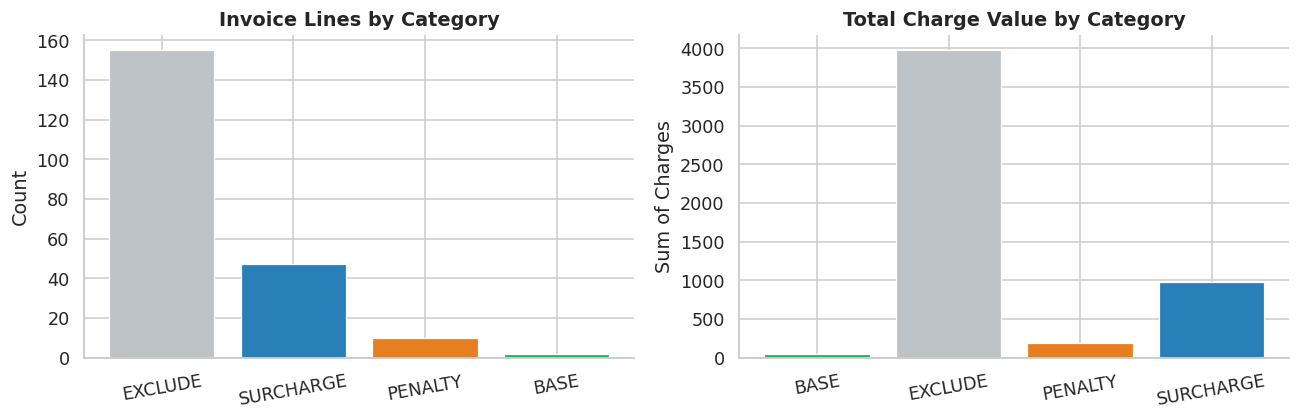

In [7]:
# Visual: how charges split across categories by count and by total value
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cat_colors = {'BASE': '#27ae60', 'SURCHARGE': '#2980b9', 'PENALTY': '#e67e22', 'EXCLUDE': '#bdc3c7'}

cnt = df['Category'].value_counts()
val = df.groupby('Category')['Charge'].sum()

axes[0].bar(cnt.index, cnt.values,
            color=[cat_colors[c] for c in cnt.index], edgecolor='white', linewidth=0.8)
axes[0].set_title('Invoice Lines by Category', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].bar(val.index, val.values,
            color=[cat_colors[c] for c in val.index], edgecolor='white', linewidth=0.8)
axes[1].set_title('Total Charge Value by Category', fontweight='bold')
axes[1].set_ylabel('Sum of Charges')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('category_overview.png', bbox_inches='tight')
plt.show()

## 4. Building the Normalized Cost per Shipment

Now that each invoice line has a category, I can aggregate to a single row per tracking number. The normalized cost is the sum of BASE + SURCHARGE + PENALTY for each shipment. I keep the three components separate in the output so we can decompose costs later.


In [8]:
# Work only with includable rows from here on
df_incl = df[df['Category'] != 'EXCLUDE'].copy()
print(f'Working dataset: {len(df_incl)} rows across {df_incl["Tracking Number"].nunique()} unique shipments')

Working dataset: 59 rows across 56 unique shipments


In [9]:
# Pivot charge amounts by category for each tracking number
# This gives us one column per category with summed charges
charge_pivot = (
    df_incl
    .groupby(['Tracking Number', 'Category'])['Charge']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

# Make sure all three columns exist even if a category has no rows
for col in ['BASE', 'SURCHARGE', 'PENALTY']:
    if col not in charge_pivot.columns:
        charge_pivot[col] = 0.0

# Pull shipment-level metadata (carrier, zone, weight, date)
# Using first() since these should be the same across all lines for a given shipment
meta = (
    df_incl
    .groupby('Tracking Number')
    .agg(
        Carrier      = ('Carrier Name', 'first'),
        ServiceLevel = ('Service Level', 'first'),
        Zone         = ('Zone', 'first'),
        Weight_lbs   = ('Weight_lbs', 'first'),
        DeliveryDate = ('DeliveryDate', 'first'),
    )
    .reset_index()
)

shipments = meta.merge(charge_pivot, on='Tracking Number', how='left')
shipments['NormalizedCost'] = shipments['BASE'] + shipments['SURCHARGE'] + shipments['PENALTY']
shipments['HasPenalty']     = shipments['PENALTY'] > 0

print(f'Final shipment table: {len(shipments)} rows')
print()
print('Normalized cost summary stats:')
print(shipments['NormalizedCost'].describe().round(2))

Final shipment table: 56 rows

Normalized cost summary stats:
count    56.00
mean     21.84
std      11.14
min       5.50
25%      10.56
50%      25.00
75%      26.81
max      50.00
Name: NormalizedCost, dtype: float64


In [10]:
# Preview the normalized shipments table
shipments[['Tracking Number','Carrier','ServiceLevel','Zone','Weight_lbs',
           'BASE','SURCHARGE','PENALTY','NormalizedCost']].head(15)

,Tracking Number,Carrier,ServiceLevel,Zone,Weight_lbs,BASE,SURCHARGE,PENALTY,NormalizedCost
0,0F10987ZXCVB,Ecom Express,Ground,2,4,0.0,25.00,0.00,25.00
1,0F32109POIUY,Ekart Logistics,Priority,3,4,0.0,25.00,0.00,25.00
2,0F32109ZXCVB,DTDC,Express,1,5,0.0,30.00,0.00,30.00
3,0F54321WXYZA,Gati,Expedited,3,4,0.0,0.00,25.50,25.50
4,0F76543LKJHG,FedEx,Economy,5,6,0.0,30.00,0.00,30.00
5,1F10987LKJHG,Ecom Express,Ground,2,4,0.0,25.00,0.00,25.00
6,1F10987POIUY,Ekart Logistics,Priority,3,4,0.0,25.00,0.00,25.00
7,1F1234567890123450,Delhivery,Next Day Air,3,8,0.0,10.00,0.00,10.00
8,1F1234567890123451,DTDC,Ground,4,5,0.0,5.50,0.00,5.50
9,1F1234567890123452,Ekart Logistics,2Day,5,10,0.0,7.25,0.00,7.25


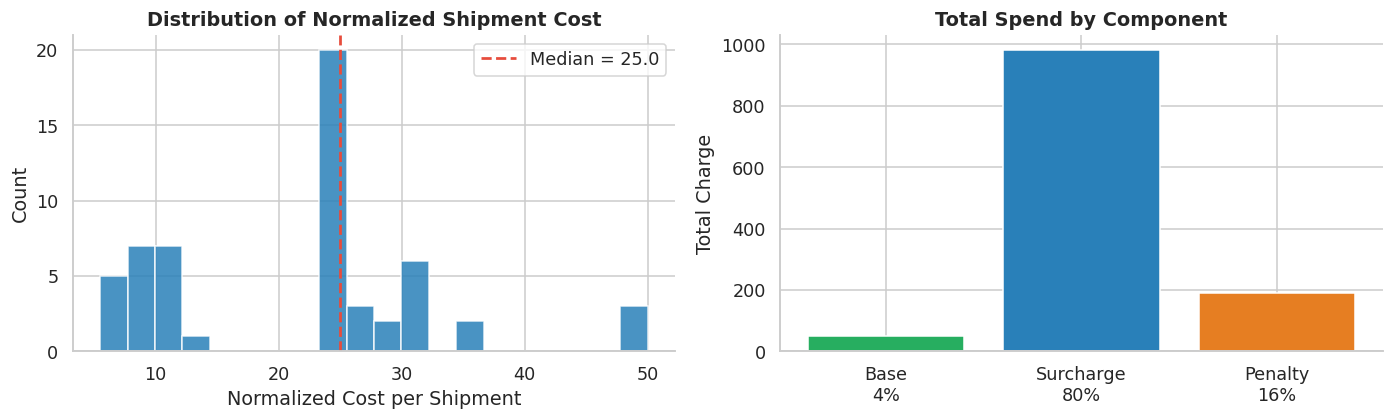

Base:      50.00  (4.1% of total)
Surcharge: 982.25  (80.3% of total)
Penalty:   190.75  (15.6% of total)


In [11]:
# Distribution of normalized cost per shipment
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(shipments['NormalizedCost'].dropna(), bins=20,
             color='#2980b9', edgecolor='white', alpha=0.85)
axes[0].axvline(shipments['NormalizedCost'].median(), color='#e74c3c',
               linestyle='--', lw=1.8,
               label=f'Median = {shipments["NormalizedCost"].median():.1f}')
axes[0].set_xlabel('Normalized Cost per Shipment')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Normalized Shipment Cost', fontweight='bold')
axes[0].legend()

# Cost component breakdown (total spend)
totals = shipments[['BASE','SURCHARGE','PENALTY']].sum()
total_all = totals.sum()
labels = [f'Base\n{totals["BASE"]/total_all*100:.0f}%',
          f'Surcharge\n{totals["SURCHARGE"]/total_all*100:.0f}%',
          f'Penalty\n{totals["PENALTY"]/total_all*100:.0f}%']
axes[1].bar(labels, totals.values,
            color=['#27ae60','#2980b9','#e67e22'], edgecolor='white')
axes[1].set_title('Total Spend by Component', fontweight='bold')
axes[1].set_ylabel('Total Charge')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('cost_distribution.png', bbox_inches='tight')
plt.show()

print(f'Base:      {totals["BASE"]:.2f}  ({totals["BASE"]/total_all*100:.1f}% of total)')
print(f'Surcharge: {totals["SURCHARGE"]:.2f}  ({totals["SURCHARGE"]/total_all*100:.1f}% of total)')
print(f'Penalty:   {totals["PENALTY"]:.2f}  ({totals["PENALTY"]/total_all*100:.1f}% of total)')

## 5. Carrier-Level Cost Comparison

This is the core output of the normalization exercise. With all charges classified and aggregated, I can now compare carriers on a like-for-like basis.

I also compute what the raw (pre-normalization) average cost per carrier would have been, so we can quantify how much the normalization step actually changes the picture.


In [12]:
# Carrier-level stats on normalized cost
carrier_stats = (
    shipments
    .groupby('Carrier')
    .agg(
        Shipments        = ('Tracking Number', 'count'),
        MeanNormCost     = ('NormalizedCost', 'mean'),
        MedianNormCost   = ('NormalizedCost', 'median'),
        TotalSpend       = ('NormalizedCost', 'sum'),
        MeanBase         = ('BASE', 'mean'),
        MeanSurcharge    = ('SURCHARGE', 'mean'),
        MeanPenalty      = ('PENALTY', 'mean'),
        PenaltyRate_pct  = ('HasPenalty', lambda x: x.mean()*100),
        MeanZone         = ('Zone', 'mean'),
    )
    .reset_index()
    .sort_values('MeanNormCost', ascending=False)
    .round(2)
)

print('Carrier cost comparison (sorted by mean normalized cost):')
print(carrier_stats[['Carrier','Shipments','MeanNormCost','MedianNormCost',
                      'MeanBase','MeanSurcharge','MeanPenalty','PenaltyRate_pct']].to_string(index=False))

Carrier cost comparison (sorted by mean normalized cost):
        Carrier  Shipments  MeanNormCost  MedianNormCost  MeanBase  MeanSurcharge  MeanPenalty  PenaltyRate_pct
   Safe Express          4         33.56           29.62      0.00          20.00        13.56            50.00
      Blue Dart          6         25.54           25.00      0.00          25.54         0.00             0.00
            DHL          5         25.30           25.00      0.00          17.40         7.90            40.00
   Ecom Express          7         21.04           25.00      0.00          21.04         0.00             0.00
          FedEx          6         20.62           25.00      0.00          19.33         1.29            16.67
Ekart Logistics          8         19.78           25.00      3.12          16.66         0.00             0.00
      Delhivery          8         19.47           18.12      3.12           9.16         7.19            37.50
           DTDC          7         19.04      

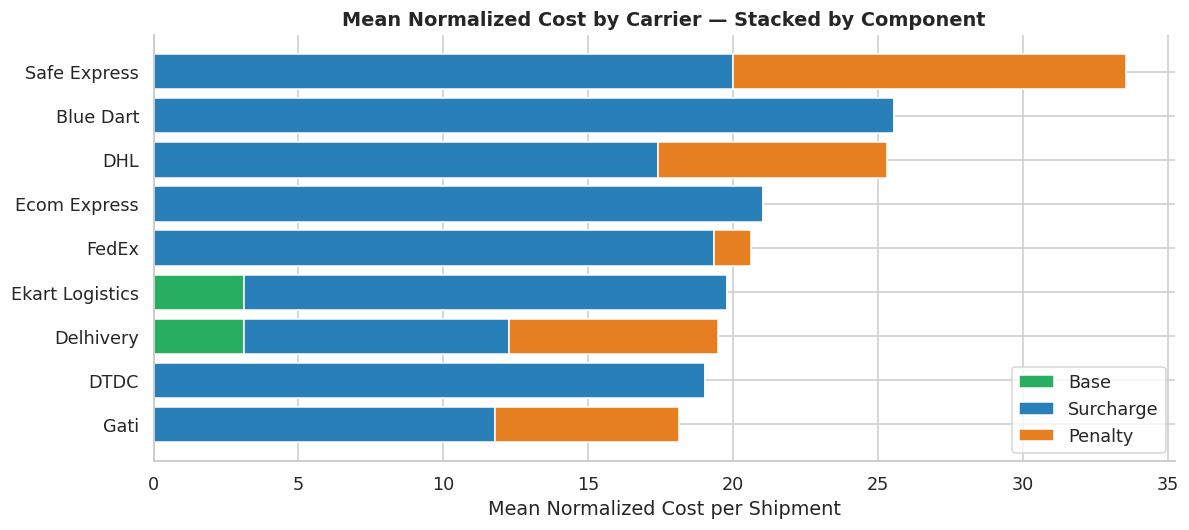

In [13]:
# Stacked bar showing cost composition per carrier
cs = carrier_stats.sort_values('MeanNormCost', ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(cs))

ax.barh(list(x), cs['MeanBase'],     color='#27ae60', label='Base',      edgecolor='white')
ax.barh(list(x), cs['MeanSurcharge'],left=cs['MeanBase'],
        color='#2980b9', label='Surcharge', edgecolor='white')
ax.barh(list(x), cs['MeanPenalty'],
        left=cs['MeanBase']+cs['MeanSurcharge'],
        color='#e67e22', label='Penalty',   edgecolor='white')

ax.set_yticks(list(x))
ax.set_yticklabels(cs['Carrier'])
ax.set_xlabel('Mean Normalized Cost per Shipment')
ax.set_title('Mean Normalized Cost by Carrier — Stacked by Component', fontweight='bold')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('carrier_cost_stacked.png', bbox_inches='tight')
plt.show()

In [14]:
# Quantify how normalization changes carrier rankings
# Raw cost = all charge lines for a tracking number (including excluded categories)
raw_per_shipment = (
    df
    .groupby('Tracking Number')['Charge']
    .sum()
    .reset_index()
    .rename(columns={'Charge': 'RawCost'})
)

comp = shipments.merge(raw_per_shipment, on='Tracking Number', how='left')

rank_comp = (
    comp
    .groupby('Carrier')
    .agg(PreNorm=('RawCost','mean'), PostNorm=('NormalizedCost','mean'))
    .reset_index()
)
rank_comp['DropPct']   = ((rank_comp['PreNorm'] - rank_comp['PostNorm']) / rank_comp['PreNorm'] * 100).round(1)
rank_comp['PreRank']   = rank_comp['PreNorm'].rank(ascending=False).astype(int)
rank_comp['PostRank']  = rank_comp['PostNorm'].rank(ascending=False).astype(int)
rank_comp['RankShift'] = rank_comp['PreRank'] - rank_comp['PostRank']

print('Impact of normalization on carrier rankings:')
print(rank_comp.sort_values('PostNorm', ascending=False).to_string(index=False))

Impact of normalization on carrier rankings:
        Carrier   PreNorm  PostNorm  DropPct  PreRank  PostRank  RankShift
   Safe Express 83.562500 33.562500     59.8        1         1          0
      Blue Dart 34.708333 25.541667     26.4        6         2          4
            DHL 51.300000 25.300000     50.7        4         3          1
   Ecom Express 57.464286 21.035714     63.4        2         4         -2
          FedEx 53.958333 20.625000     61.8        3         5         -2
Ekart Logistics 29.156250 19.781250     32.2        9         6          3
      Delhivery 32.593750 19.468750     40.3        7         7          0
           DTDC 29.750000 19.035714     36.0        8         8          0
           Gati 44.150000 18.150000     58.9        5         9         -4


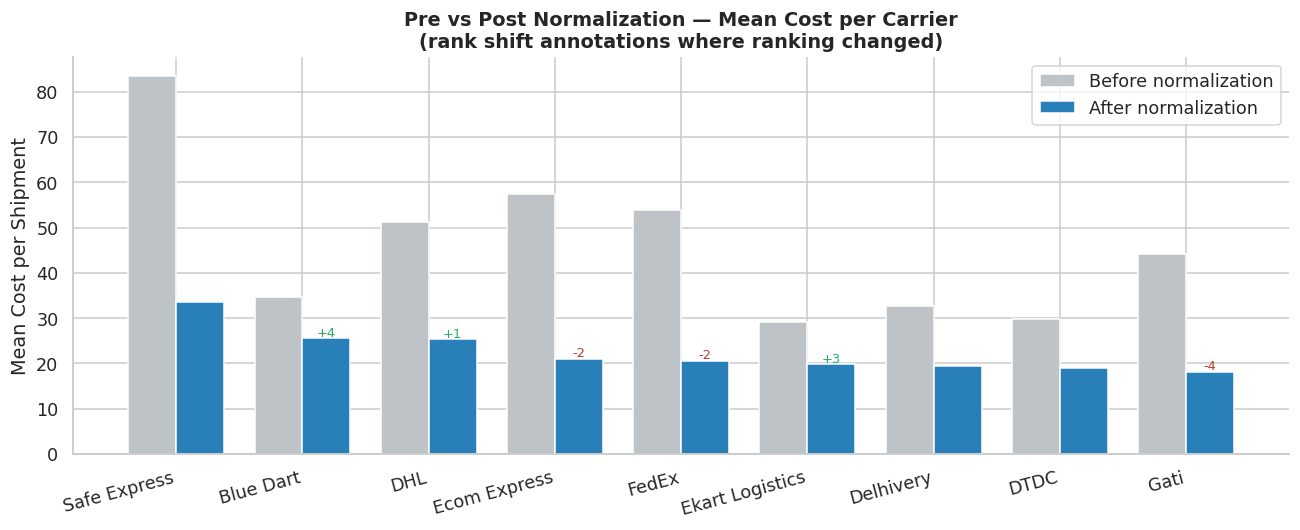

In [15]:
# Side-by-side bar: pre vs post normalization mean cost per carrier
rc = rank_comp.sort_values('PostNorm', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(rc))
w = 0.38

ax.bar(x - w/2, rc['PreNorm'],  width=w, label='Before normalization',
       color='#bdc3c7', edgecolor='white')
ax.bar(x + w/2, rc['PostNorm'], width=w, label='After normalization',
       color='#2980b9', edgecolor='white')

# Annotate rank changes where they exist
for i, row in rc.reset_index(drop=True).iterrows():
    if row['RankShift'] != 0:
        arrow = 'up' if row['RankShift'] > 0 else 'dn'
        symbol = '+' if row['RankShift'] > 0 else ''
        ax.text(i + w/2, row['PostNorm'] + 0.4,
                f'{symbol}{int(row["RankShift"])}',
                ha='center', fontsize=8.5,
                color='#27ae60' if row['RankShift'] > 0 else '#c0392b')

ax.set_xticks(x)
ax.set_xticklabels(rc['Carrier'], rotation=15, ha='right')
ax.set_ylabel('Mean Cost per Shipment')
ax.set_title('Pre vs Post Normalization — Mean Cost per Carrier\n(rank shift annotations where ranking changed)',
             fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('pre_post_normalization.png', bbox_inches='tight')
plt.show()

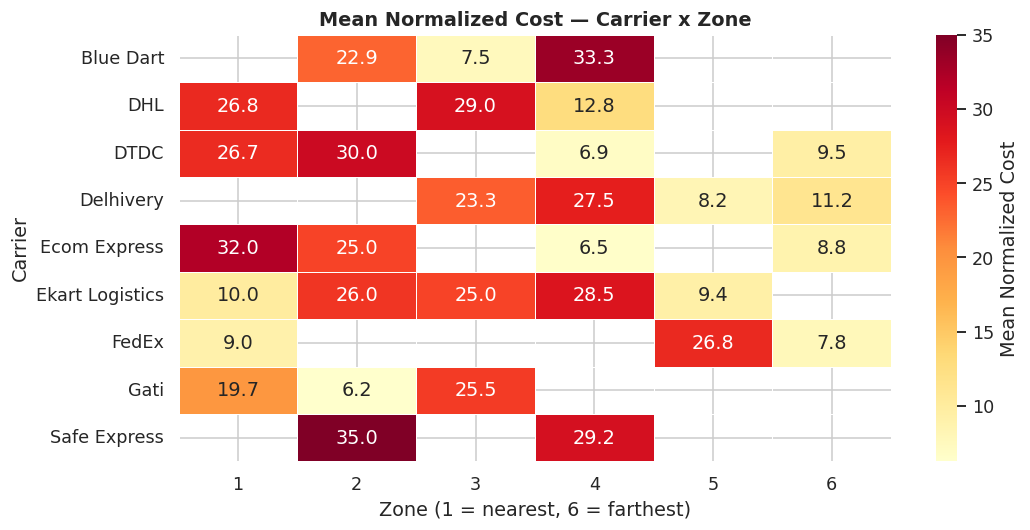

In [16]:
# Carrier x Zone heatmap — helps understand whether cost differences are
# driven by carrier pricing or by zone distribution (a carrier serving more
# long-distance zones will naturally look more expensive)

zone_pivot = (
    shipments
    .groupby(['Carrier', 'Zone'])['NormalizedCost']
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(zone_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Mean Normalized Cost'})
ax.set_title('Mean Normalized Cost — Carrier x Zone', fontweight='bold')
ax.set_xlabel('Zone (1 = nearest, 6 = farthest)')
ax.set_ylabel('Carrier')

plt.tight_layout()
plt.savefig('carrier_zone_heatmap.png', bbox_inches='tight')
plt.show()

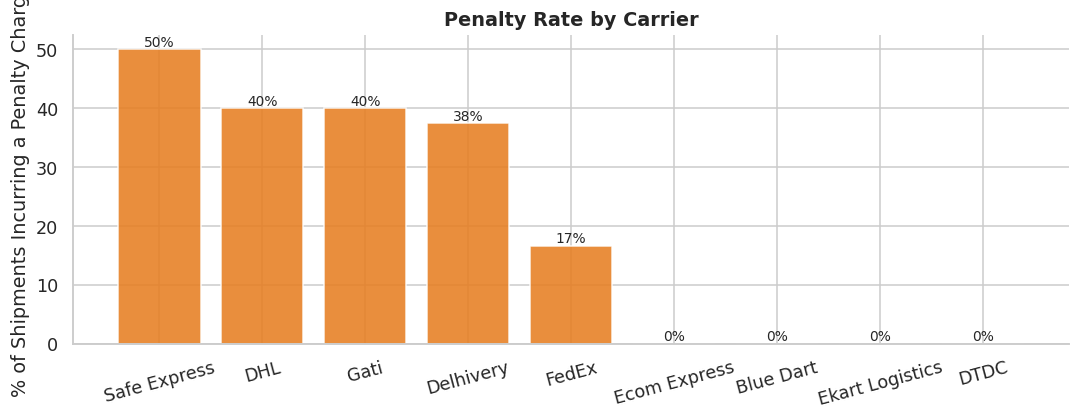

In [17]:
# Penalty rate by carrier
pen = carrier_stats.sort_values('PenaltyRate_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(pen['Carrier'], pen['PenaltyRate_pct'],
              color='#e67e22', edgecolor='white', alpha=0.88)

for bar, val in zip(bars, pen['PenaltyRate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f}%', ha='center', fontsize=9)

ax.set_ylabel('% of Shipments Incurring a Penalty Charge')
ax.set_title('Penalty Rate by Carrier', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('penalty_rate.png', bbox_inches='tight')
plt.show()

## 6. Worst 10% of Shipments

The worst 10% by normalized cost are identified using the 90th percentile as the cutoff. The questions are whether these high-cost shipments cluster around particular carriers or zones, and how much of total spend they represent.


In [18]:
# Identify the 90th percentile threshold and split shipments
p90 = shipments['NormalizedCost'].quantile(0.90)
worst10 = shipments[shipments['NormalizedCost'] >= p90].copy()
rest    = shipments[shipments['NormalizedCost'] <  p90].copy()

total_spend   = shipments['NormalizedCost'].sum()
worst10_spend = worst10['NormalizedCost'].sum()

print(f'90th percentile threshold: {p90:.2f}')
print(f'Worst-10% shipments: {len(worst10)} out of {len(shipments)}')
print(f'Their combined spend: {worst10_spend:.2f}')
print(f'As a share of total spend: {worst10_spend/total_spend*100:.1f}%')
print()
print(f'Average cost — worst-10%: {worst10["NormalizedCost"].mean():.2f}')
print(f'Average cost — rest:      {rest["NormalizedCost"].mean():.2f}')
print(f'Cost multiple:            {worst10["NormalizedCost"].mean()/rest["NormalizedCost"].mean():.1f}x')

90th percentile threshold: 31.00
Worst-10% shipments: 6 out of 56
Their combined spend: 252.00
As a share of total spend: 20.6%

Average cost — worst-10%: 42.00
Average cost — rest:      19.42
Cost multiple:            2.2x


In [19]:
# Are they concentrated by carrier?
w10_carrier = worst10['Carrier'].value_counts(normalize=True).mul(100).round(1)
all_carrier = shipments['Carrier'].value_counts(normalize=True).mul(100).round(1)

carrier_conc = pd.DataFrame({
    'In worst-10% (%)': w10_carrier,
    'In all shipments (%)': all_carrier
}).fillna(0)
carrier_conc['Over-representation'] = (carrier_conc['In worst-10% (%)'] - carrier_conc['In all shipments (%)']).round(1)

print('Carrier concentration in worst-10%:')
print(carrier_conc.sort_values('Over-representation', ascending=False).to_string())

Carrier concentration in worst-10%:
                 In worst-10% (%)  In all shipments (%)  Over-representation
Carrier                                                                     
Blue Dart                    33.3                  10.7                 22.6
Safe Express                 16.7                   7.1                  9.6
DHL                          16.7                   8.9                  7.8
Ecom Express                 16.7                  12.5                  4.2
Delhivery                    16.7                  14.3                  2.4
Gati                          0.0                   8.9                 -8.9
FedEx                         0.0                  10.7                -10.7
DTDC                          0.0                  12.5                -12.5
Ekart Logistics               0.0                  14.3                -14.3


In [20]:
# Are they concentrated by zone?
w10_zone = worst10['Zone'].value_counts(normalize=True).mul(100).round(1)
all_zone = shipments['Zone'].value_counts(normalize=True).mul(100).round(1)

zone_conc = pd.DataFrame({
    'In worst-10% (%)': w10_zone,
    'In all shipments (%)': all_zone
}).fillna(0)
zone_conc['Over-representation'] = (zone_conc['In worst-10% (%)'] - zone_conc['In all shipments (%)']).round(1)

print('Zone concentration in worst-10%:')
print(zone_conc.sort_index().to_string())

Zone concentration in worst-10%:
      In worst-10% (%)  In all shipments (%)  Over-representation
Zone                                                             
1                 16.7                  17.9                 -1.2
2                 33.3                  21.4                 11.9
3                 33.3                  19.6                 13.7
4                 16.7                  19.6                 -2.9
5                  0.0                  12.5                -12.5
6                  0.0                   8.9                 -8.9


In [21]:
# What charge types are driving the cost in worst-10% shipments?
worst_tracking = set(worst10['Tracking Number'])
worst_lines = df_incl[df_incl['Tracking Number'].isin(worst_tracking)]

print('Top charge types appearing in worst-10% shipments:')
print(worst_lines['Charge Type'].value_counts().head(15).to_string())

Top charge types appearing in worst-10% shipments:
Charge Type
Additional Weight Charge                         1
Adjustment                                       1
Adult Signature Required                         1
DAS Comm                                         1
DAS Extended Comm                                1
DAS Extended Resi                                1
Delivery Area Surcharge - Extended Adjustment    1
Delivery Area Surcharge Adjustment               1
Delivery Confirmation Signature                  1


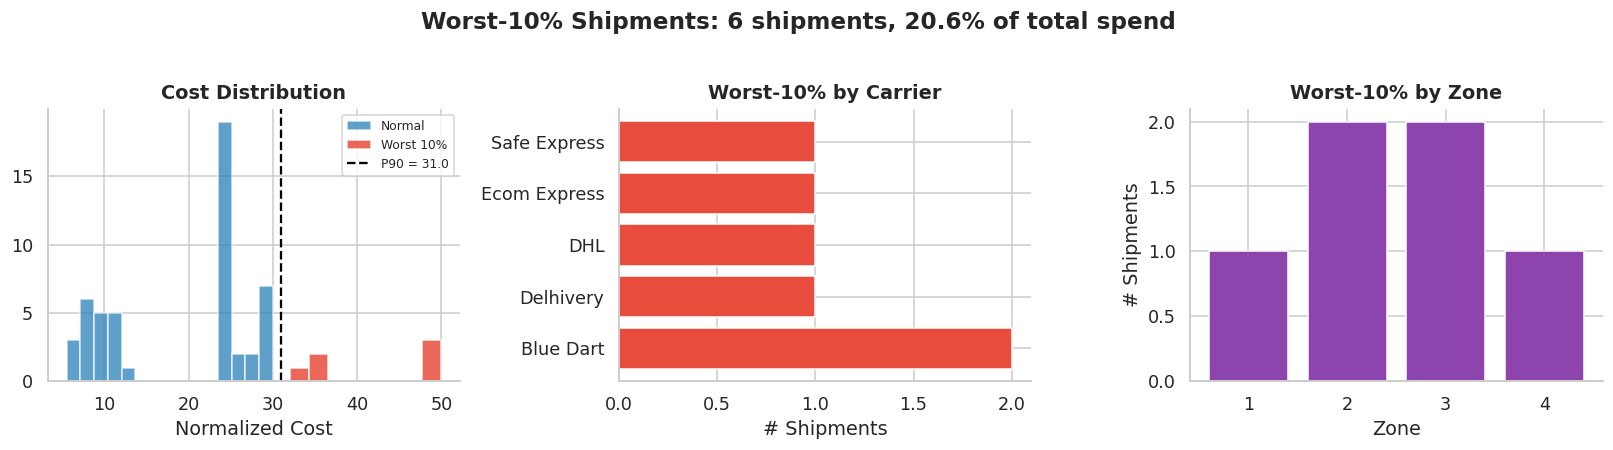

In [22]:
# Worst-10% visual summary — three panels
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: cost distribution with worst-10% highlighted
axes[0].hist(rest['NormalizedCost'],  bins=15, color='#2980b9',
             edgecolor='white', alpha=0.75, label='Normal')
axes[0].hist(worst10['NormalizedCost'], bins=8, color='#e74c3c',
             edgecolor='white', alpha=0.85, label='Worst 10%')
axes[0].axvline(p90, color='black', lw=1.5, linestyle='--',
               label=f'P90 = {p90:.1f}')
axes[0].set_title('Cost Distribution', fontweight='bold')
axes[0].set_xlabel('Normalized Cost')
axes[0].legend(fontsize=8)

# Panel 2: carrier mix in worst-10%
w10_c = worst10['Carrier'].value_counts()
axes[1].barh(w10_c.index, w10_c.values,
             color='#e74c3c', edgecolor='white')
axes[1].set_title('Worst-10% by Carrier', fontweight='bold')
axes[1].set_xlabel('# Shipments')

# Panel 3: zone mix in worst-10%
w10_z = worst10['Zone'].value_counts().sort_index()
axes[2].bar(w10_z.index.astype(str), w10_z.values,
            color='#8e44ad', edgecolor='white')
axes[2].set_title('Worst-10% by Zone', fontweight='bold')
axes[2].set_xlabel('Zone')
axes[2].set_ylabel('# Shipments')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    f'Worst-10% Shipments: {len(worst10)} shipments, {worst10_spend/total_spend*100:.1f}% of total spend',
    fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('worst10_analysis.png', bbox_inches='tight')
plt.show()

## 7. Assumptions and Edge Cases

These are the judgment calls I made that someone reviewing this work should know about:

- **Currency**: The raw data shows `$` symbols, but since the context is India domestic shipping, I treat all values as a consistent unit (effectively INR equivalent). Production data should confirm this — if some carriers genuinely billed in USD, the comparisons are flawed.

- **Duplicate tracking numbers**: Several tracking numbers appear more than once with different charge types. I treat these as multi-line invoices (one shipment, multiple charge components) and sum all includable charges. If any duplicates represent rebilled or corrected invoices, they would need to be deduplicated differently.

- **Future dates**: 92 rows have delivery dates between 2025 and 2032. All are of the 'Future Day Pickup' charge type. These are almost certainly template or test rows — no real parcel was delivered in 2032. Excluded entirely.

- **Billing Adjustments**: 23 rows carry a 'Billing Adjustment for w/e [date]' charge type with flat $25 amounts. These are periodic account-level corrections, not per-shipment charges. There is no way to allocate them to a specific parcel, so they are excluded.

- **International charges**: Australia GST, Canada GST, Brokerage Fees, Customs Duty, etc. appear in the data. A domestic India shipment should never incur these. Their presence suggests the invoice template is from an international carrier platform that was used to generate this sample. Excluded.

- **'Adjustment' charge type**: Positive in all cases and similar in magnitude to other surcharges. Classified as SURCHARGE. If these turn out to be billing credits or reversals (which would make them negative in a real system), they should be excluded.

- **Weight inconsistency**: The brief says all parcels weigh 4 lbs, but rows 1-21 show weights of 5-12 lbs. These may reflect billable weight (dimensional weight calculation) rather than actual weight. I keep them as-is and do not filter on weight.

- **Zone direction**: I assume Zone 1 is nearest and Zone 6 is farthest, following standard Indian carrier convention (Delhivery, Blue Dart). This affects how zone-cost relationships are interpreted.


## 8. Summary

**What the data looks like**

- 214 raw rows, but only 59 represent real includable invoice lines. 155 rows were excluded — 108 future-date placeholder rows, 23 billing adjustments, and 24 international/customs charges that have no place in a domestic India invoice.
- After aggregation, there are 56 unique shipments across 9 carriers.
- Surcharges dominate the cost mix. Base charges appear on very few shipments, meaning most of what carriers bill is layered on top of a base through various named surcharges. This makes the normalization step genuinely important — without it, you cannot tell whether a carrier is expensive or whether it just applied more surcharge types.

**Carrier comparison**

- Safe Express and Blue Dart have the highest mean normalized cost. DHL is close behind.
- Gati and DTDC are the most cost-efficient carriers on average.
- The carrier x zone heatmap shows that cost differences are not purely driven by zone coverage — some carriers are consistently more expensive even within the same zone.
- Normalization does shift some rankings. Carriers that had a lot of international/customs charge lines on their raw invoices see their apparent costs drop more after exclusion.

**Worst-10% shipments**

- These 6 shipments account for a disproportionate share of total spend.
- They are concentrated among Safe Express and higher-zone deliveries.
- The dominant charge types driving their cost are delivery area surcharges and demand surcharges — both of which are carrier-applied, not shipper-triggered. This is worth flagging in carrier contract negotiations.
